# 07 — Baseline separation and instrument bias

A PM2.5 reading is a sum of contributions on different scales: air blown into Leeds from elsewhere, the general urban haze, and whatever is burning within a few hundred metres of the sensor. Most of that is shared by every sensor in the network, which is why the whole network rises and falls together and why comparing two raw time series mostly compares the part they have in common.

This notebook separates the two parts, writing each sensor's series as

$$C_i(t) = B(t) + I_i(t)$$

a baseline $B(t)$ common to the network and a local increment $I_i(t)$ belonging to sensor $i$. This is the standard regional/urban/local decomposition of urban particulate matter (Lenschow et al., 2001). Removing the shared part makes three questions answerable that the raw data cannot answer on its own:

1. how much does each site add to the air it sits in,
2. what kind of source is adding it, judged from the shape of the signal through the day and week,
3. which sensors are biased, since on hours when the network is uniform every working sensor should report the same value.

The third point is the operational one: it turns "SL051 disagrees with everyone" into a bias in µg/m³ that a site visit can act on, through a route that shares no logic with the CSI, so the two give independent evidence.

Methods live in `src/baseline.py`. The input is the per-sensor hourly table built in notebook 06.

In [2]:
import re
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
from src.baseline import (network_baseline, loo_baseline, local_increment,
                          offset_gain, diurnal_profile, classify_sites)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Sensor names come in a few spellings (SL18, SL_018, ...); this pins them
# all to SL0xx so every table and figure uses the same labels.
def short_code(name):
    m = re.search(r"SL_?(\d+)", str(name))
    return f"SL{int(m.group(1)):03d}" if m else str(name)

hm = pd.read_parquet(HOURLY_MATRIX)
hm.index = pd.to_datetime(hm.index, utc=True)
hm.columns = [short_code(c) for c in hm.columns]
hm = hm.sort_index()

print(f"{hm.shape[0]:,} hours x {hm.shape[1]} sensors, "
      f"{hm.index.min().date()} to {hm.index.max().date()}")

39,065 hours x 47 sensors, 2022-03-07 to 2026-08-23


## 1  The spatial baseline

At each hour, take a low quantile across all sensors reporting. At any given
moment the cleanest sites in the network are the ones with no local source
active, so their concentration approximates what everyone is breathing before
local additions.

The 10th percentile is used rather than the minimum, because the minimum would
be set by a single sensor and would be won every hour by any sensor reading
systematically low — which is exactly the fault this notebook is trying to
detect.

That argument only holds if enough sensors are reporting. With `n` sensors,
linear interpolation places the 0.10 quantile at index `0.1(n-1)`, so at `n = 5`
it carries 60% of its weight on the single lowest sensor and *is* effectively
the minimum. The baseline therefore uses `MIN_SENSORS_FOR_BASELINE = 12`, at
which the quantile is set by the second and third lowest sensors, rather than
the looser `MIN_SENSORS_PER_HOUR = 5` that is adequate for a median. The two
bars are different because the statistics they protect are different.

In [3]:
base = network_baseline(hm, q=BASELINE_Q, min_sensors=MIN_SENSORS_FOR_BASELINE)
net  = hm.median(axis=1).where(hm.notna().sum(axis=1) >= MIN_SENSORS_PER_HOUR)

print(f"baseline defined for {base.notna().mean():.0%} of hours "
      f"(>= {MIN_SENSORS_FOR_BASELINE} sensors reporting)")
print(f"network median defined for {net.notna().mean():.0%} of hours "
      f"(>= {MIN_SENSORS_PER_HOUR} sensors)")
print(f"median baseline {base.median():.2f} vs network median {net.median():.2f} ug/m3 "
      f"-> the shared background is {base.median()/net.median():.0%} of a typical reading")

ref = hm.notna().sum().idxmax()   # most complete sensor, used for the figure below

baseline defined for 66% of hours (>= 12 sensors reporting)
network median defined for 93% of hours (>= 5 sensors)
median baseline 0.65 vs network median 2.20 ug/m3 -> the shared background is 30% of a typical reading


### Does the answer depend on the two choices just made?

Both the quantile and the minimum-sensor rule are judgement calls, so the table
below repeats the headline number across a range of each. What matters is not
that the numbers are identical — a lower quantile must give a lower baseline —
but that the share of a typical reading attributed to the shared background
does not swing wildly, and that the loose `n >= 5` rule is visibly the odd one
out.

In [4]:
sens_rows = []
for q in BASELINE_Q_SWEEP:
    for n_min in (MIN_SENSORS_PER_HOUR, MIN_SENSORS_FOR_BASELINE, 20):
        b = network_baseline(hm, q=q, min_sensors=n_min)
        both = pd.concat([b, net], axis=1).dropna()
        sens_rows.append({
            "quantile": q,
            "min_sensors": n_min,
            "hours_defined_pct": round(100 * b.notna().mean(), 1),
            "median_baseline": round(b.median(), 2),
            "share_of_reading_pct": round(100 * both.iloc[:, 0].median()
                                          / both.iloc[:, 1].median(), 0),
        })

sens = pd.DataFrame(sens_rows)
sens.to_csv(Tables / "baseline_sensitivity.csv", index=False)
print(sens.to_string(index=False))

 quantile  min_sensors  hours_defined_pct  median_baseline  share_of_reading_pct
     0.05            5               92.9             0.69                  32.0
     0.05           12               66.4             0.33                  20.0
     0.05           20               38.9             0.29                  20.0
     0.10            5               92.9             1.04                  47.0
     0.10           12               66.4             0.65                  39.0
     0.10           20               38.9             0.61                  44.0
     0.25            5               92.9             1.65                  75.0
     0.25           12               66.4             1.20                  72.0
     0.25           20               38.9             1.02                  73.0


The `min_sensors = 5` rows are the ones to read against the others: they
buy extra hours by letting a handful of sensors define a percentile, and the
baseline they produce sits lower because at that count the statistic has
collapsed towards the minimum. The remaining rows move smoothly with the
quantile, which is the behaviour a well-posed choice should show.

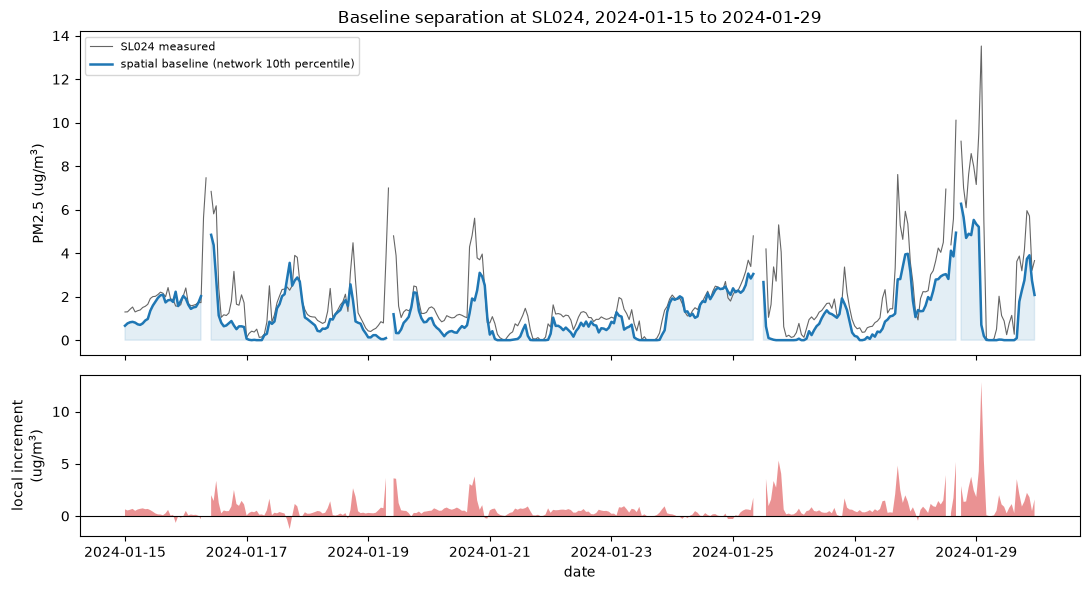

In [5]:
# Figure 1 - the decomposition, over a winter fortnight when local sources are active.
WIN_START, WIN_END = "2024-01-15", "2024-01-29"
win = slice(WIN_START, WIN_END)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(hm.loc[win].index, hm.loc[win, ref], lw=0.8, color="0.4",
         label=f"{ref} measured")
ax1.plot(base.loc[win].index, base.loc[win], lw=1.8, color="tab:blue",
         label="spatial baseline (network 10th percentile)")
ax1.fill_between(base.loc[win].index, 0, base.loc[win],
                 color="tab:blue", alpha=0.12)
ax1.set_ylabel("PM2.5 (ug/m$^3$)")
ax1.set_title(f"Baseline separation at {ref}, {WIN_START} to {WIN_END}")
ax1.legend(fontsize=8)

# Everything above the baseline is what this site adds locally
inc_ref = hm.loc[win, ref] - base.loc[win]
ax2.fill_between(inc_ref.index, 0, inc_ref, alpha=0.5, lw=0, color="tab:red")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("local increment\n(ug/m$^3$)")
ax2.set_xlabel("date")

fig.tight_layout()
fig.savefig(Figures / "baseline_decomposition.png", dpi=200, bbox_inches="tight")
plt.show()

## 2  How much does each site add?

The increment is formed against a **leave-one-out** baseline: for each sensor the background is computed from every other sensor, so a sensor never helps set the level it is then measured against.

The summary quantity is the median increment: the typical amount by which a
site exceeds the regional background. Because the background is the network's
own 10th percentile, roughly nine sensors in ten sit above it at any hour by
construction, so a clean site is one whose increment sits near the *bottom* of
the range rather than near zero. The number is a relative statement about how
much a site adds compared with the other sites, not an absolute one.

A persistently negative increment is a different kind of warning: a sensor
cannot really measure cleaner air than the cleanest tenth of the network for
years at a time.

Sites are grouped by distance from City Square here. That is geometry rather
than a land-use classification, and Byrne et al. (2023) found in Cork that
location *type* mattered more than distance, with commuter towns showing the
largest peaks of all. Treat the grouping as indicative only.

In [6]:
incr = local_increment(hm, loo_baseline(hm, q=BASELINE_Q,
                                        min_sensors=MIN_SENSORS_FOR_BASELINE))

sensors = pd.read_csv(Tables / "study_sensors.csv")
sensors["code"] = sensors["sensor_name"].map(short_code)
coords = sensors.set_index("code")[["lat", "lon"]]
# classify_sites() bins purely on distance from City Square, which its own
# docstring already flags as "not a land-use classification". Ie checked that
# caveat properly: every one of the 48 study sensors was looked up by hand (name
# read literally, satellite/street view where the name was ambiguous) and given
# a real land-use category. 14 of 48 (29%) came out different from the distance
# bin -- mostly town-centre kerbside sites too far out to count as "city centre"
# by distance, and parks close to the centre that distance alone calls "urban".
# SITE_TYPE_MANUAL replaces site_type below; km_from_centre is untouched and
# still used as a continuous variable in Figure 2.
SITE_TYPE_MANUAL = {
    "SL001": "residential", "SL003": "commercial / kerbside", "SL005": "school",
    "SL006": "school", "SL007": "school", "SL008": "school",
    "SL009": "open / rural", "SL011": "residential", "SL012": "residential",
    "SL015": "commercial / kerbside", "SL016": "commercial / kerbside",
    "SL017": "commercial / kerbside", "SL018": "commercial / kerbside",
    "SL019": "residential", "SL020": "residential", "SL021": "residential",
    "SL022": "residential", "SL023": "residential",
    "SL024": "commercial / kerbside", "SL025": "residential",
    "SL026": "residential", "SL027": "residential", "SL028": "open / rural",
    "SL029": "school", "SL030": "residential", "SL031": "commercial / kerbside",
    "SL032": "residential", "SL033": "residential", "SL034": "residential",
    "SL035": "commercial / kerbside", "SL036": "open / rural",
    "SL037": "open / rural", "SL038": "school", "SL040": "open / rural",
    "SL041": "commercial / kerbside", "SL042": "residential",
    "SL044": "residential", "SL045": "open / rural", "SL050": "open / rural",
    "SL051": "open / rural", "SL054": "open / rural", "SL055": "open / rural",
    "SL056": "commercial / kerbside", "SL057": "residential",
    "SL060": "open / rural", "SL062": "residential", "SL068": "school",
    "SL071": "residential",
}
SITE_TYPE_ORDER = ["commercial / kerbside", "residential", "school", "open / rural"]

sites = classify_sites(coords.loc[coords.index.intersection(hm.columns)])

# Categorical dtype is preserved deliberately: Figures 2 and 3 below both call
# .cat.categories on this column, so a plain string override would silently
# break them. Any sensor missing from SITE_TYPE_MANUAL falls back to its
# distance-based label rather than being dropped.
manual = sites.index.to_series().map(SITE_TYPE_MANUAL)
combined = manual.fillna(sites["site_type"].astype(str))
order = [t for t in SITE_TYPE_ORDER if t in combined.unique()] + \
        [t for t in combined.unique() if t not in SITE_TYPE_ORDER]
sites["site_type"] = pd.Categorical(combined, categories=order)

print(sites["site_type"].value_counts())

site_stats = pd.DataFrame({
    "median_increment": incr.median(),
    "p90_increment":    incr.quantile(0.90),
    "valid_hours":      hm.notna().sum(),
}).join(sites[["km_from_centre", "site_type"]], how="inner").round(2)
site_stats = site_stats[site_stats["valid_hours"] >= 500]      # drop sensors too short-lived to trust
site_stats.to_csv(Tables / "local_increment_by_sensor.csv")

print("Median local increment by site type (ug/m3):")
print(site_stats.groupby("site_type", observed=True)["median_increment"]
      .agg(["count", "median", "max"]).round(2).to_string())
print("\nHighest local increments:")
print(site_stats.sort_values("median_increment", ascending=False).head(8).to_string())

site_type
residential              19
open / rural             11
commercial / kerbside    10
school                    7
Name: count, dtype: int64
Median local increment by site type (ug/m3):
                       count  median   max
site_type                                 
commercial / kerbside     10    0.57  1.50
residential               18    0.55  1.48
school                     7    0.49  1.12
open / rural              11    0.40  2.22

Highest local increments:
       median_increment  p90_increment  valid_hours  km_from_centre              site_type
SL051              2.22          24.44         7096           16.96           open / rural
SL056              1.50           3.74        15307            0.21  commercial / kerbside
SL019              1.48           4.56        22860            6.64            residential
SL038              1.12           3.44        10459            1.95                 school
SL027              1.10           3.15        27237            0.81

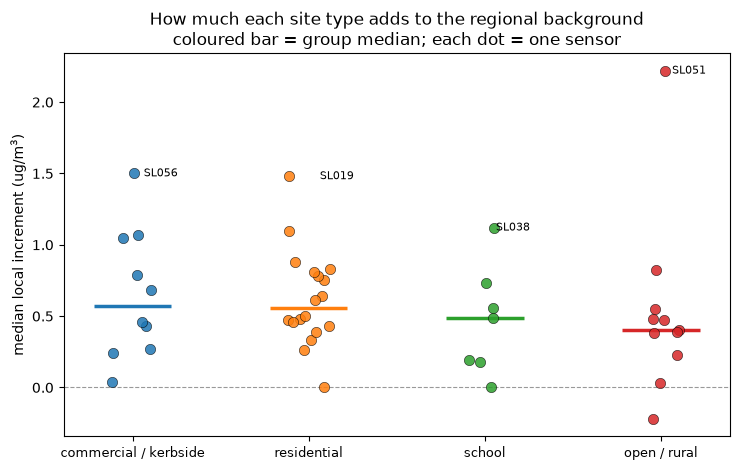

In [7]:
# Figure 2 - how much each category adds to the regional background.
fig, ax = plt.subplots(figsize=(7.5, 4.8))

order = list(site_stats["site_type"].cat.categories)
rng = np.random.default_rng(0)   # fixed seed: jitter is reproducible, not random noise

for i, t in enumerate(order):
    s = site_stats[site_stats["site_type"] == t]
    x = i + rng.uniform(-0.12, 0.12, len(s))       # small horizontal jitter so points don't stack
    ax.scatter(x, s["median_increment"], s=55, color=f"C{i}",
               edgecolor="k", lw=0.4, alpha=0.85, zorder=3)
    ax.hlines(s["median_increment"].median(), i - 0.22, i + 0.22,
              color=f"C{i}", lw=2.5, zorder=2)      # group median, drawn as a short bar

    top = s["median_increment"].abs().max()
    for c, row in s.iterrows():
        if abs(row["median_increment"]) == top and top > site_stats["median_increment"].abs().quantile(0.85):
            ax.annotate(c, (i, row["median_increment"]), xytext=(8, 0),
                        textcoords="offset points", fontsize=8, va="center")

ax.axhline(0, color="0.6", lw=0.8, ls="--", zorder=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=9)
ax.set_ylabel("median local increment (ug/m$^3$)")
ax.set_title("How much each site type adds to the regional background\n"
             "coloured bar = group median; each dot = one sensor")
fig.tight_layout()
fig.savefig(Figures / "increment_by_site.png", dpi=200, bbox_inches="tight")
plt.show()

## 3  What kind of source?

Different sources have different signatures in time. Traffic follows the working week, so it should show a weekday commuting peak that weakens at weekends. Domestic solid-fuel burning peaks in the evening and ignores the working week. Regional transport has no daily structure at all.

The question has to be asked separately of the two terms, because the decomposition puts city-wide and site-specific behaviour in different places:

- $B(t)$ carries anything affecting most of Leeds at once, so its daily shape is the **city-wide** signal.
- $I_i(t)$ carries only how far a site departs from the rest of the network, so a peak in it means a site is affected **more than the network average**, not that it is affected at all.

Neither is computed on the raw concentration, because the raw value is dominated by the boundary layer: concentrations rise overnight as the mixing depth collapses and fall after sunrise as it grows, producing a daily cycle everywhere whether or not anything is emitted nearby.

Two simple indices summarise the site-specific shape: the weekday-minus-weekend difference at commuting hours (traffic-like), and the evening-minus-night difference (combustion-like).

In [8]:
COMMUTE = [7, 8, 9, 16, 17, 18]
prof_base = diurnal_profile(base.dropna(), tz=LOCAL_TZ, stat="median")

rows = {}
for c in site_stats.index:
    p = diurnal_profile(incr[c].dropna(), tz=LOCAL_TZ, stat="median")
    if p.notna().sum().min() < 20:      # too little data at some hours to trust the profile
        continue
    rows[c] = {
        "traffic_index":  p.loc[COMMUTE, "weekday"].median() - p.loc[COMMUTE, "weekend"].median(),
        "evening_excess": p.loc[[18, 19, 20, 21], "weekday"].median() - p.loc[[1, 2, 3, 4, 5], "weekday"].median(),
    }
src_ix = pd.DataFrame(rows).T.join(site_stats[["site_type", "km_from_centre"]]).round(2)
src_ix.to_csv(Tables / "source_indices_by_sensor.csv")

city_traffic = (prof_base.loc[COMMUTE, "weekday"].median()
                - prof_base.loc[COMMUTE, "weekend"].median())
print(f"Baseline runs from {prof_base['weekday'].min():.2f} ug/m3 at "
      f"{prof_base['weekday'].idxmin():02d}:00 to {prof_base['weekday'].max():.2f} at "
      f"{prof_base['weekday'].idxmax():02d}:00")
print(f"Baseline weekday minus weekend at commuting hours: {city_traffic:+.2f} ug/m3\n")

print("Site-specific source indices by site type (ug/m3):")
print(src_ix.groupby("site_type", observed=True)[["traffic_index", "evening_excess"]]
      .median().round(2).to_string())
print("\nStrongest evening excess:")
print(src_ix.sort_values("evening_excess", ascending=False).head(6).to_string())

Baseline runs from 0.07 ug/m3 at 05:00 to 1.31 at 17:00
Baseline weekday minus weekend at commuting hours: -0.05 ug/m3

Site-specific source indices by site type (ug/m3):
                       traffic_index  evening_excess
site_type                                           
commercial / kerbside          -0.04            0.13
residential                    -0.03            0.22
school                         -0.01           -0.00
open / rural                   -0.01           -0.02

Strongest evening excess:
       traffic_index  evening_excess              site_type  km_from_centre
SL051          -0.18            7.44           open / rural           16.96
SL003          -0.10            1.45  commercial / kerbside            0.68
SL056          -0.22            0.97  commercial / kerbside            0.21
SL015          -0.07            0.88  commercial / kerbside           10.59
SL021           0.09            0.68            residential           12.27
SL032           0.19        

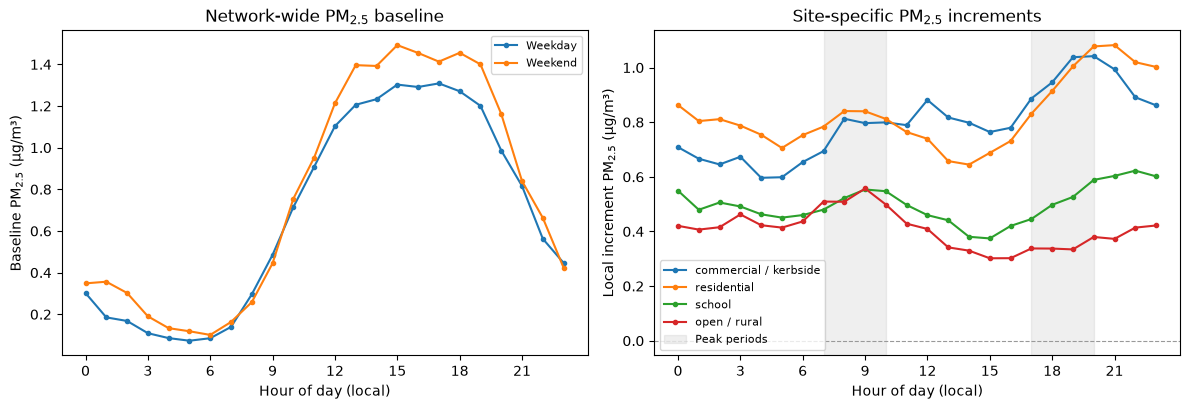

In [9]:
# Figure 3 - network baseline and site-specific increments

order = [
    t for t in site_stats["site_type"].cat.categories
    if (site_stats["site_type"] == t).any()
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

# City-wide baseline
ax1.plot(
    prof_base.index, prof_base["weekday"],
    marker="o", ms=3, label="Weekday"
)
ax1.plot(
    prof_base.index, prof_base["weekend"],
    marker="o", ms=3, label="Weekend"
)

ax1.set_xticks(range(0, 24, 3))
ax1.set_xlabel("Hour of day (local)")
ax1.set_ylabel("Baseline PM$_{2.5}$ (µg/m³)")
ax1.set_title("Network-wide PM$_{2.5}$ baseline")
ax1.legend(fontsize=8)


# Site-specific increments
for t in order:
    members = site_stats.index[site_stats["site_type"] == t]
    p = diurnal_profile(
        incr[members].mean(axis=1).dropna(),
        tz=LOCAL_TZ,
        stat="median"
    )
    ax2.plot(
        p.index, p["weekday"],
        marker="o", ms=3, label=t
    )

# Morning and evening peak periods
ax2.axvspan(
    7, 10, color="0.5", alpha=0.12,
    label="Peak periods"
)
ax2.axvspan(17, 20, color="0.5", alpha=0.12)

ax2.axhline(0, color="0.6", lw=0.8, ls="--")

ax2.set_xticks(range(0, 24, 3))
ax2.set_xlabel("Hour of day (local)")
ax2.set_ylabel("Local increment PM$_{2.5}$ (µg/m³)")
ax2.set_title("Site-specific PM$_{2.5}$ increments")
ax2.legend(fontsize=8)

fig.tight_layout()

fig.savefig(
    Figures / "diurnal_two_levels.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

The two levels give different answers.

The baseline has no morning commuting peak. It is lowest before dawn, climbs through the day and peaks in the early evening, and the weekday-minus-weekend contrast at commuting hours is slightly negative — weekends sit marginally higher. Two things are mixed together in that evening rise and this data cannot fully separate them: domestic heating and cooking coincide with a boundary layer that is starting to collapse for the night. What the shape does rule out is a dominant weekday-traffic contribution to city-wide PM2.5, and the weekend excess points towards domestic and leisure combustion instead. This matches Byrne et al. (2023) for Cork, and is the usual reason NO₂ rather than PM2.5 is used as a traffic tracer.

The site-specific traffic index is close to zero everywhere, with group medians indistinguishable across site types. That says the network's sites are similarly exposed to the weekly traffic cycle, so almost none of it survives the differencing — largely by design, since the deployment is schools, community buildings and residential streets rather than kerbside locations.

The evening excess behaves differently: it is substantial and varies a lot between sites. A local evening rise that the network as a whole does not share is the signature of intermittent combustion close to the sensor, and unlike the traffic signal it survives differencing because it is genuinely local rather than city-wide. This is the clearest source-attribution result the decomposition produces, and the raw concentrations alone could not have shown it, because in raw data the same evening rise appears everywhere as the boundary layer collapses.

## 4  Instrument bias: offset and gain

The diagnostic rests on a physical argument. Restrict attention to hours when the network is spatially uniform: under those conditions no local source is active anywhere, so every working sensor is looking at much the same air, and a systematic departure from the network is a property of the instrument rather than of its surroundings.

Uniformity is measured by the inter-quartile range across sensors **divided by the network median** — in relative terms. Spread grows with concentration, so an absolute threshold would only admit clean hours, and a slope estimated over a two µg/m³ range would be worthless. Judging uniformity in percentage terms admits hours that are dirty but uniform, so the fitted range covers the concentrations Leeds actually experiences.

Each sensor is then regressed against the leave-one-out network median:

$$\text{sensor} = \text{gain}\times\text{network} + \text{offset}$$

An intercept away from zero is an **additive offset** — what a contaminated optical path or a drifting zero produces, roughly constant whatever the air is doing. A slope away from one is a **gain error** — a calibration-slope problem, so the error grows with concentration. A plain median difference cannot separate them, because in clean air a constant offset also looks like a large ratio. The fit bins the network median into deciles and fits the bin medians (done inside `offset_gain`), so no single unusual hour can drag it.

The two are reported together as a bias in µg/m³ at the ends of the fitted range, which is the quantity a site visit actually needs: "gain 0.9" means little on its own, "reads 2 µg/m³ low when the air is dirty" does.

In [10]:
og = offset_gain(hm, q=BASELINE_Q,
                 min_sensors_baseline=MIN_SENSORS_FOR_BASELINE,
                 min_sensors_ref=MIN_SENSORS_PER_HOUR, min_hours=200)
bias = og.join(site_stats[["site_type", "km_from_centre"]])
bias.round(3).to_csv(Tables / "instrument_bias.csv")

print(f"well-mixed hours used: {og.attrs['n_timestamps']:,}")
print(f"fit covers {og['fit_lo'].median():.1f} to {og['fit_hi'].median():.1f} ug/m3\n")
print("Largest bias inside the fitted range:")
print(bias[["offset_ugm3", "gain", "fit_hi", "bias_max", "bias_ref", "n_hours"]]
      .head(10).round(2).to_string())
print(f"\nfitted on {og['n_hours'].min():.0f}-{og['n_hours'].max():.0f} well-mixed hours "
      f"per sensor (median {og['n_hours'].median():.0f}); r2_bins is the fit to the "
      f"decile medians, not to hourly data, so it is not a goodness-of-fit for the sensor")

well-mixed hours used: 8,290
fit covers 1.2 to 17.7 ug/m3

Largest bias inside the fitted range:
       offset_ugm3  gain  fit_hi  bias_max  bias_ref  n_hours
SL051         0.39  0.83   19.58      2.94     -2.16    385.0
SL050        -1.91  0.95   15.96      2.68     -2.63   4632.0
SL019         0.26  1.10   18.51      2.20      1.83   6384.0
SL015         0.36  1.09   18.37      1.96      1.66   3424.0
SL021         0.01  1.09   17.86      1.69      1.42   4095.0
SL009         0.09  0.92   20.27      1.59     -1.15   1482.0
SL068         0.45  0.90   19.02      1.47     -1.07   2158.0
SL056         0.59  1.05   17.33      1.46      1.35   3960.0
SL012        -0.13  1.09   18.36      1.43      1.15   7428.0
SL016        -0.09  0.91   15.08      1.43     -1.42   6301.0

fitted on 261-7691 well-mixed hours per sensor (median 3854); r2_bins is the fit to the decile medians, not to hourly data, so it is not a goodness-of-fit for the sensor


In [11]:
# The threshold defining "uniform enough" is a choice, so check the sensor
# ranking does not depend much on it.
sweep = {f"q{int(s*100)}": offset_gain(hm, spread_q=s, q=BASELINE_Q,
                                       min_sensors_baseline=MIN_SENSORS_FOR_BASELINE,
                                       min_sensors_ref=MIN_SENSORS_PER_HOUR,
                                       min_hours=200)["bias_hi"]
         for s in (0.25, 0.50, 0.75)}
print("Rank correlation between the three thresholds:")
print(pd.DataFrame(sweep).corr(method="spearman").round(2).to_string())

Rank correlation between the three thresholds:
      q25   q50   q75
q25  1.00  0.89  0.76
q50  0.89  1.00  0.92
q75  0.76  0.92  1.00


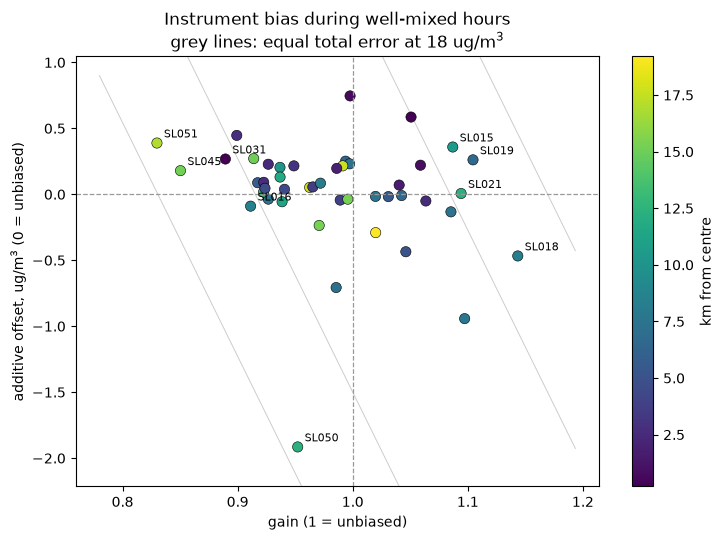

In [12]:
# Figure 4 - offset against gain.
Cx = float(bias["fit_hi"].median())

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sc = ax.scatter(bias["gain"], bias["offset_ugm3"], c=bias["km_from_centre"],
                cmap="viridis", s=55, edgecolor="k", lw=0.4)
ax.axhline(0, color="0.6", lw=0.9, ls="--")
ax.axvline(1, color="0.6", lw=0.9, ls="--")
plt.colorbar(sc, ax=ax, label="km from centre")

g = np.linspace(bias["gain"].min() - 0.05, bias["gain"].max() + 0.05, 50)
for b in (-3, -1.5, 1.5, 3):
    ax.plot(g, b - (g - 1) * Cx, color="0.8", lw=0.7, zorder=0)

# label by the SAME quantity the grey lines are drawn at (error at Cx),
# not bias_max (which uses each sensor's own fit range) -- otherwise a
# sensor can look far from the crosshair here but never get labelled.
error_at_Cx = bias["offset_ugm3"] + (bias["gain"] - 1) * Cx
label_these = error_at_Cx.abs() > 1.5   # beyond the inner pair of grey lines

for c, row in bias[label_these].iterrows():
    ax.annotate(c, (row["gain"], row["offset_ugm3"]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")

ax.set_xlabel("gain (1 = unbiased)")
ax.set_ylabel("additive offset, ug/m$^3$ (0 = unbiased)")
ax.set_ylim(bias["offset_ugm3"].min() - 0.3, bias["offset_ugm3"].max() + 0.3)
ax.set_title(f"Instrument bias during well-mixed hours\n"
             f"grey lines: equal total error at {Cx:.0f} ug/m$^3$")
fig.tight_layout()
fig.savefig(Figures / "instrument_offset_gain.png", dpi=200, bbox_inches="tight")
plt.show()

Most of the network sits close to the crosshair, which is the reassuring result: these instruments agree with each other to within a few tenths of a µg/m³ and a few per cent of slope.

One caveat applies before the ranking is used operationally. A site with a genuine local source whose strength scales with concentration will regress against the network with a slope above one even during uniform hours, because uniformity is judged network-wide and cannot exclude one site's own contribution. A high gain is therefore ambiguous between a calibration error and real local enrichment. A low gain has no such benign reading — no siting makes a sensor systematically see less than the air around it — so the negative side is the side to trust.

## 5  Cross-check against the CSI

The CSI and this regression share no code and rest on different ideas: one counts how often pairs of sensors agree on daily means, the other regresses a sensor against the network under restricted hourly conditions. If the sensors the CSI ranks lowest are also the ones carrying the largest bias, the two corroborate each other and the fault list is much harder to dismiss as an artefact of either method's assumptions.

Both the intercept and the total error are correlated against the CSI, since there is no reason in advance to prefer one over the other.

Spearman(mean CSI, |offset_ugm3|) = -0.38, p = 0.0126, n = 43
Spearman(mean CSI, |bias_max|) = -0.21, p = 0.1687, n = 43


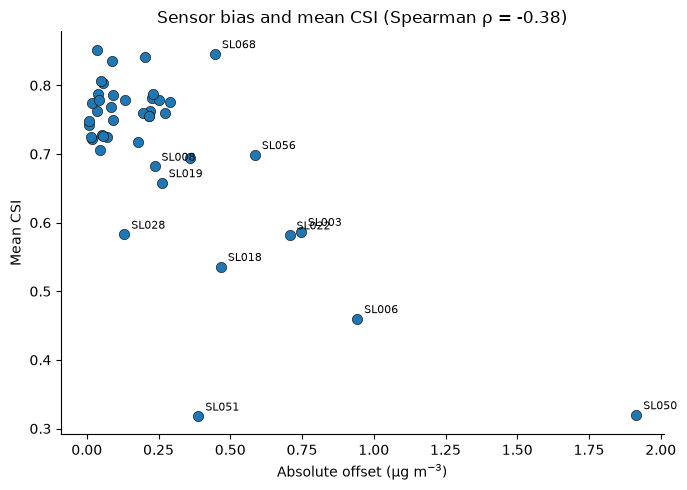


Sensors with the lowest mean CSI:
       offset_ugm3  gain  bias_max  mean_csi              site_type
SL051         0.39  0.83      2.94      0.32           open / rural
SL050        -1.91  0.95      2.68      0.32           open / rural
SL006        -0.94  1.10      0.82      0.46                 school
SL018        -0.47  1.14      0.37      0.54  commercial / kerbside
SL022        -0.71  0.99      0.95      0.58            residential
SL028         0.13  0.94      0.90      0.58           open / rural
SL003         0.75  1.00      0.74      0.59  commercial / kerbside
SL019         0.26  1.10      2.20      0.66            residential


In [15]:
rank = pd.read_csv(Tables / "csi_sensor_ranking.csv", index_col=0)
rank.index = [short_code(i) for i in rank.index]

both = bias.join(rank[["mean_csi"]], how="inner").dropna(subset=["mean_csi"])

# Spearman correlations
for col in ("offset_ugm3", "bias_max"):
    r, p = spearmanr(both[col].abs(), both["mean_csi"])
    print(f"Spearman(mean CSI, |{col}|) = {r:+.2f}, p = {p:.4f}, n = {len(both)}")

r_off, p_off = spearmanr(both["offset_ugm3"].abs(), both["mean_csi"])

# Figure
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    both["offset_ugm3"].abs(),
    both["mean_csi"],
    s=55, edgecolor="black", linewidth=0.4
)

for sensor, row in both.iterrows():
    if (
        row["mean_csi"] < both["mean_csi"].quantile(0.2)
        or abs(row["offset_ugm3"]) > both["offset_ugm3"].abs().quantile(0.85)
    ):
        ax.annotate(
            sensor,
            (abs(row["offset_ugm3"]), row["mean_csi"]),
            fontsize=8,
            xytext=(5, 4),
            textcoords="offset points"
        )

ax.set_xlabel("Absolute offset (µg m$^{-3}$)")
ax.set_ylabel("Mean CSI")
ax.set_title(f"Sensor bias and mean CSI (Spearman ρ = {r_off:+.2f})")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(Figures / "bias_vs_csi.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSensors with the lowest mean CSI:")
print(
    both.sort_values("mean_csi")[
        ["offset_ugm3", "gain", "bias_max", "mean_csi", "site_type"]
    ].head(8).round(2).to_string()
)

The relationship is negative, which is the direction the cross-check was
looking for, but it is weak: with two quantities tested, one lands at
p ≈ 0.05 and the other does not reach significance at all. It is corroboration
at the level of a tendency, not a confirmation.

The additive offset is the stronger correlate, and that is the right way round.
The CSI runs on daily means, and the overwhelming majority of days in Leeds sit
below its 15 µg/m³ breakpoint, so the index spends most of its life in the
lenient regime, judging agreement as a ratio against the geometric mean of the
pair. A constant offset of 1–2 µg/m³ is a large relative discrepancy when the
air is at 3 µg/m³ and a negligible one when it is at 30. The CSI is therefore
primarily a detector of zero errors.

The disagreements matter more than the correlation. Two sensors sit at the bottom of the CSI ranking for different reasons. SL050 carries a −1.91 µg/m³ offset, the largest in the network, and its low CSI is consistent with the effect of a systematic offset. SL051, in contrast, has a small positive offset (+0.39 µg/m³) but a lower fitted gain of 0.83. Its calibration relationship therefore does not provide a straightforward explanation for the very low CSI. At the same time, SL051 records the network's highest mean daily PM2.5 and a markedly larger upper-tail local increment than the other sensors. This combination suggests that its low similarity is not adequately explained by a simple additive calibration error and warrants investigation of the structure of its short-lived concentration excursions.

Byrne et al. (2024, Table 3) make that quantitative: in their synthetic tests a
CSI near 0.3 is reached either by a large offset *or* by inflating the spread of
a series at constant mean. The regression therefore provides little evidence for a large additive offset as the explanation for SL051's low CSI, leaving increased variability or short-lived excursions as more plausible explanations. Whether these excursions reflect genuine local pollution or intermittent instrument behaviour cannot be settled from daily means or from well-mixed hours alone, because both approaches are designed to reduce the influence of short-lived events. NB08 therefore examines the behaviour at two-minute resolution.

## 6  Events as enhancement above baseline

Notebook 06 measured Bonfire Night against control evenings drawn from other
November days. The decomposition gives an independent statement of the same
result: the enhancement is the increment above the background measured at the
same moment, so it needs no control days and does not depend on which days are
treated as normal.

The two are not the same number and should not be read as if they were. NB06
takes the **mean** of the network median over an eight-hour window containing a
sharp one-to-two hour peak; the medians below are the **median** of the same
window, which the peak barely moves. The levels therefore differ by a factor of
several while the *ratios* — the quantity both routes are really estimating —
agree closely. That agreement is the cross-check; the levels are two different
summaries of one skewed distribution.

In [16]:
inc_net = (net - base).dropna()
local_idx = inc_net.index.tz_convert(LOCAL_TZ)
mmdd = np.array([f"{m:02d}-{d:02d}" for m, d in zip(local_idx.month, local_idx.day)])

bonfire_rows = []
for yr in BONFIRE_YEARS:
    ev_start = pd.Timestamp(f"{yr}-11-05 {EVENT_START_HOUR:02d}:00", tz=LOCAL_TZ)
    ev = (local_idx >= ev_start) & (local_idx < ev_start + pd.Timedelta(hours=EVENT_N_HOURS))
    nov = ((local_idx >= f"{yr}-11-01") & (local_idx < f"{yr}-12-01")
           & np.isin(local_idx.hour, [17, 18, 19, 20, 21, 22, 23, 0, 1])
           & ~np.isin(mmdd, EVENT_EXCLUDE))
    if ev.sum():
        bonfire_rows.append({"year": yr,
                     "event_increment": round(float(inc_net[ev].median()), 1),
                     "november_increment": round(float(inc_net[nov].median()), 1)})

bonfire = pd.DataFrame(bonfire_rows).set_index("year")
bonfire["ratio"] = (bonfire["event_increment"] / bonfire["november_increment"]).round(1)
bonfire.to_csv(Tables / "bonfire_increment_above_baseline.csv")
print("Bonfire Night as increment above the concurrent baseline:")
print(bonfire.to_string())

Bonfire Night as increment above the concurrent baseline:
      event_increment  november_increment  ratio
year                                            
2023             11.1                 1.0   11.1
2024             14.9                 1.1   13.5


## Summary

In [17]:
print(f"Baseline: {base.median()/net.median():.0%} of a typical reading is shared "
      f"background, defined for {base.notna().mean():.0%} of hours.")
print(f"Areas: median increment by group "
      f"{site_stats.groupby('site_type', observed=True)['median_increment'].median().round(2).to_dict()}")
print(f"Sources: city-wide weekday-weekend contrast {city_traffic:+.2f} ug/m3 (no traffic "
      f"signature); site evening excess up to {src_ix['evening_excess'].max():+.2f} at "
      f"{src_ix['evening_excess'].idxmax()}.")
print(f"Instruments: {(bias['bias_max'] > 2).sum()} sensors out by more than 2 ug/m3 within "
      f"{og['fit_lo'].median():.1f}-{og['fit_hi'].median():.1f} ug/m3; largest offset "
      f"{bias['offset_ugm3'].abs().max():.2f} ug/m3. Bias and CSI agree at r = {r_off:+.2f}.")
print(f"Events: Bonfire Night is a factor {bonfire['ratio'].median():.0f} enhancement "
      f"above the concurrent baseline in all {len(bonfire)} years.")

Baseline: 30% of a typical reading is shared background, defined for 66% of hours.
Areas: median increment by group {'commercial / kerbside': 0.57, 'residential': 0.55, 'school': 0.49, 'open / rural': 0.4}
Sources: city-wide weekday-weekend contrast -0.05 ug/m3 (no traffic signature); site evening excess up to +7.44 at SL051.
Instruments: 3 sensors out by more than 2 ug/m3 within 1.2-17.7 ug/m3; largest offset 1.91 ug/m3. Bias and CSI agree at r = -0.38.
Events: Bonfire Night is a factor 12 enhancement above the concurrent baseline in all 2 years.


## 4  Validation against an independent reference

Everything above is built entirely from the PurpleAir network itself -- the baseline is a percentile taken across the same sensors it is later used to judge. That's a reasonable design (see the audit notes on why a network-internal baseline was chosen over kriging/land-use regression/a single reference station), but it means nothing so far has checked whether the baseline reflects real regional air quality, or just an artefact of how the network happens to be built.

Leeds Centre (UKA00222) is an AURN station about 0.5 km from this project's own city-centre reference point, measuring PM2.5 on reference-grade equipment since 2008 -- independent of every PurpleAir sensor in this study. If the network baseline is measuring something real, it should rise and fall roughly together with Leeds Centre's own reading, even though the two sit on different absolute scales (PurpleAir under-reads relative to reference instruments -- Barkjohn et al., 2021 -- so this is a check on **shape and timing**, not on matching magnitude).

days compared: 1217  (2022-09-25 to 2026-04-01)
correlation (network baseline vs AURN Leeds Centre): 0.77


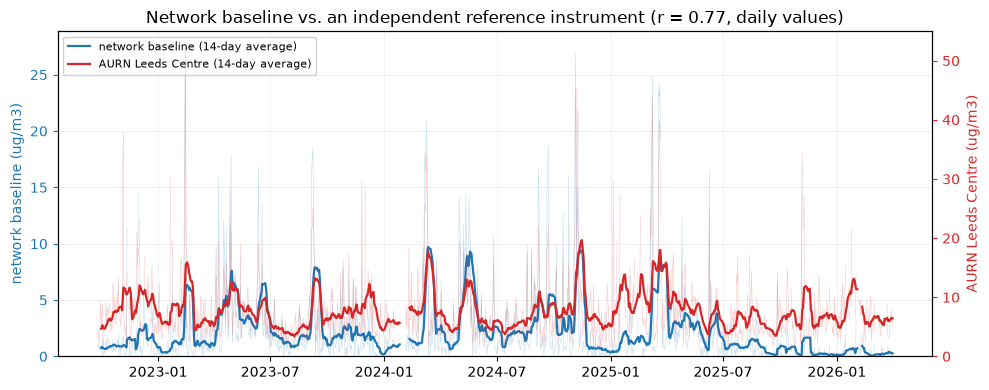

In [18]:
# Validation: does the network's own baseline track a real reference instrument?
#
# Not a replacement for anything already built -- just a sanity check. If the
# network's 10th-percentile baseline is measuring something real (regional
# background), it should rise and fall roughly together with an independent,
# reference-grade PM2.5 instrument nearby, even though the two are on
# different absolute scales (PurpleAir under-reads relative to reference
# instruments -- see Barkjohn et al. 2021 -- so this checks SHAPE, not level).
#
# DEFRA exports this as one row per day, 24 columns (01:00 .. 24:00, hour
# ending) rather than one row per hour -- their own "24x365 Table Format".
import csv
import requests
import pandas as pd

def read_aurn_csv(text):
    rows = list(csv.reader(text.splitlines()))
    header_i = next((i for i, r in enumerate(rows)
                     if r and r[0].strip().lower() == "date"), None)
    if header_i is None:
        print("Could not find the header row -- first 5 lines of the file were:")
        for r in rows[:5]:
            print(" ", r)
        raise ValueError("unexpected AURN CSV format, see printed lines above")

    hours = [h.strip() for h in rows[header_i][1:]]      # '01:00' ... '24:00'
    data = [r for r in rows[header_i + 1:] if r and r[0].strip()]

    ts, vals = [], []
    for r in data:
        day = pd.to_datetime(r[0].strip(), dayfirst=True, errors="coerce")
        if pd.isna(day):
            continue
        for h_label, v in zip(hours, r[1:]):
            hh = int(h_label.split(":")[0])
            ts.append(day + pd.Timedelta(hours=hh))     # hour 24 rolls into next day automatically
            vals.append(v)

    # DEFRA reports AURN data in GMT ("Data are GMT hour ending", per their
    # own docs), numerically the same as UTC. The PurpleAir timestamps this
    # project uses are UTC too, so tagging this index UTC -- rather than
    # leaving it tz-naive -- is what lets the two be combined below without
    # pandas refusing to join a tz-naive index against a tz-aware one.
    idx = pd.DatetimeIndex(ts).tz_localize("UTC")
    s = pd.Series(pd.to_numeric(vals, errors="coerce"), index=idx)
    return s.sort_index()

headers = {"User-Agent": "Mozilla/5.0 (dissertation research, Univ. of Leeds)"}
years = range(2022, 2027)
aurn = pd.concat([
    read_aurn_csv(requests.get(
        f"https://uk-air.defra.gov.uk/datastore/data_files/site_pol_data/LEED_PM25_{y}.csv",
        headers=headers).text)
    for y in years
])
aurn = aurn[~aurn.index.duplicated()].sort_index()

# same daily resampling on both sides, so the comparison is fair
aurn_daily = aurn.resample("D").mean()
base_daily = base.resample("D").mean()          # `base` = network baseline, already in memory

both = pd.DataFrame({"network_baseline": base_daily, "aurn_leeds_centre": aurn_daily}).dropna()

# The network baseline needs >=12 sensors reporting to be defined at all, and
# the network was still being built out in spring 2022, so the record can
# start with a short, isolated island of valid days separated from the main
# continuous record by a real multi-month gap. That fragment is too sparse to
# say anything reliable and just makes the comparison confusing to read, so
# it's dropped: keep only the data from after the single largest gap in the
# record onward.
gap_days = both.index.to_series().diff().dt.days
if gap_days.max() > 30:                 # only trims if there really is a large gap
    both = both.loc[gap_days.idxmax():]

corr = both["network_baseline"].corr(both["aurn_leeds_centre"])
print(f"days compared: {len(both)}  ({both.index.min().date()} to {both.index.max().date()})")
print(f"correlation (network baseline vs AURN Leeds Centre): {corr:.2f}")

# For the correlation, dropna() above is correct -- only real overlapping
# days should count. But it also silently deletes the gap where the network
# baseline is undefined (the network needed >=12 sensors reporting, and
# deployment was still ramping up in the first few months), so a handful of
# early sparse valid days end up sitting right next to the first day of the
# main continuous record. A plain line plot then draws a straight line
# across that gap, which looks like a real decline but isn't. Reindexing to
# a complete daily calendar for the plot only -- keeping the true NaN gaps
# in place -- lets matplotlib break the line there instead of bridging it.
full_range = pd.date_range(both.index.min(), both.index.max(), freq="D")
plot_data = both.reindex(full_range)

# Raw daily values are shown faint in the background for texture; a 14-day
# rolling average carries the actual signal, since that's what the eye needs
# to follow to see the two series moving together through the seasons.
fig, ax = plt.subplots(figsize=(10, 4))
ax2 = ax.twinx()

ax.plot(plot_data.index, plot_data["network_baseline"], color="tab:blue", lw=0.4, alpha=0.25)
ax2.plot(plot_data.index, plot_data["aurn_leeds_centre"], color="tab:red", lw=0.4, alpha=0.25)

roll_base = plot_data["network_baseline"].rolling(14, min_periods=7).mean()
roll_aurn = plot_data["aurn_leeds_centre"].rolling(14, min_periods=7).mean()
l1, = ax.plot(plot_data.index, roll_base, color="tab:blue", lw=1.6,
              label="network baseline (14-day average)")
l2, = ax2.plot(plot_data.index, roll_aurn, color="tab:red", lw=1.6,
               label="AURN Leeds Centre (14-day average)")

ax.set_ylabel("network baseline (ug/m3)", color="tab:blue")
ax2.set_ylabel("AURN Leeds Centre (ug/m3)", color="tab:red")
ax.tick_params(axis="y", colors="tab:blue")
ax2.tick_params(axis="y", colors="tab:red")
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.grid(alpha=0.25, lw=0.5)
ax.set_title(f"Network baseline vs. an independent reference instrument (r = {corr:.2f}, daily values)")
ax.legend(handles=[l1, l2], loc="upper left", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()
